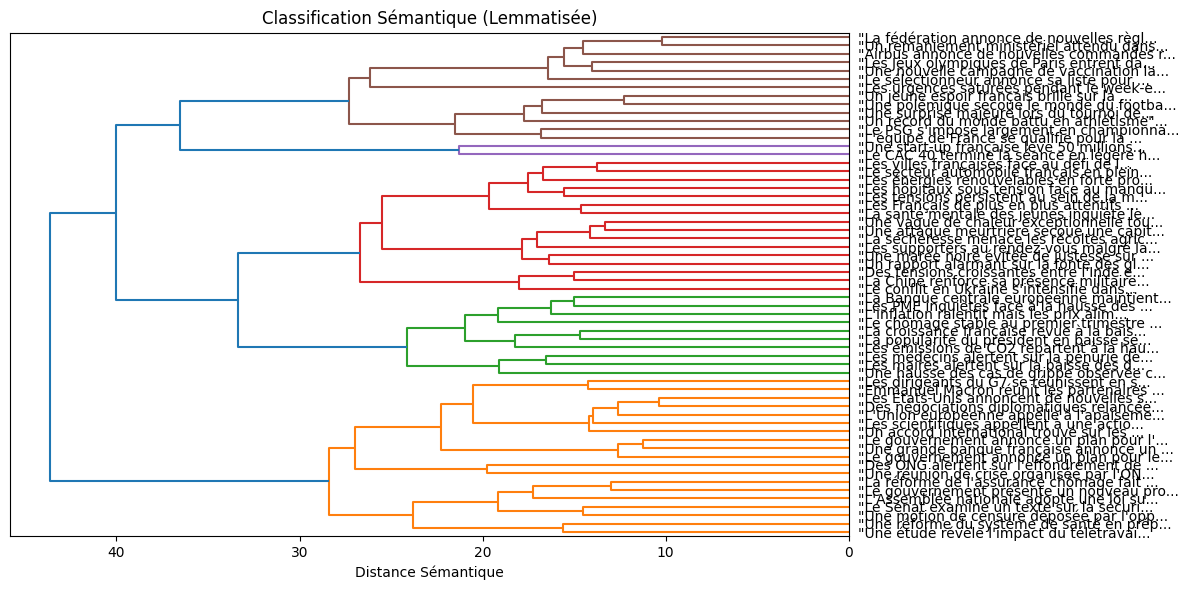

In [22]:
from pathlib import Path

import spacy

import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage

nlp = spacy.load("fr_core_news_md")

phrases = []
path = "./data/textes.txt"

with Path(path).open(encoding="utf-8") as f:
    phrases = [line.strip() for line in f if line.strip()]

vectors = []
for phrase in phrases:
    doc = nlp(phrase)
    lemmes = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
    text_clean = " ".join(lemmes)
    vectors.append(nlp(text_clean).vector)

X = np.array(vectors)

Z = linkage(X, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(
    Z, labels=[p[:40] + "..." for p in phrases], orientation="left", leaf_font_size=10,
)

plt.title("Classification Sémantique (Lemmatisée)")
plt.xlabel("Distance Sémantique")
plt.tight_layout()
plt.show()
